In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("./public/drawndata1.csv")

In [4]:
df.head()

,x,y,z
0,58.080365,225.699042,a
1,238.867357,247.456645,a
2,156.218212,286.588782,a
3,262.004361,284.251445,a
4,185.243183,308.187571,a


In [9]:
X = df[["x", "y"]].values
y = df["z"] == "a"

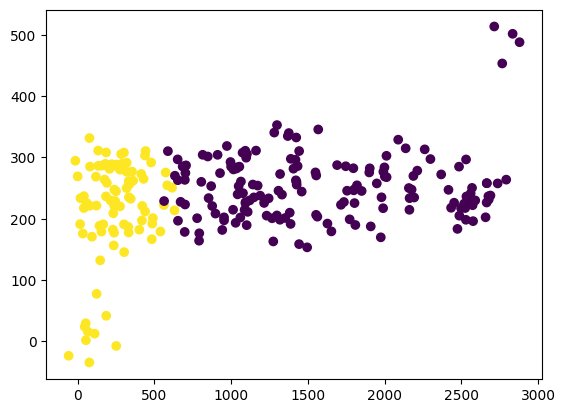

In [10]:
plt.scatter(X[:,0], X[:,1], c=y)

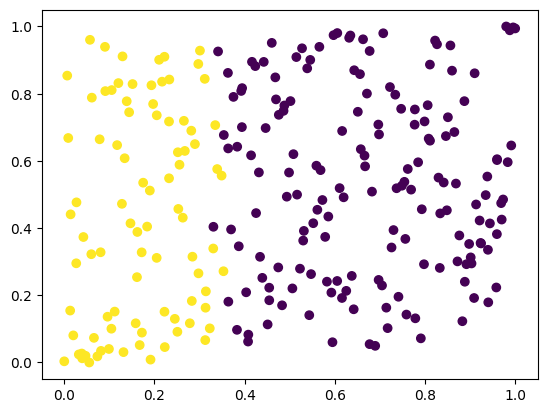

In [13]:
from sklearn.preprocessing import StandardScaler, QuantileTransformer
X_new = QuantileTransformer(n_quantiles=100).fit_transform(X)

plt.scatter(X_new[:,0],X_new[:,1], c=y)

#Still there are a few outliers hence to remove the outliers

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

def plot_output(scaler):
    pipe = Pipeline([
        ("scale", scaler),
        ("model", KNeighborsClassifier(n_neighbors=20, weights='distance'))
    ])

    pred = pipe.fit(X, y).predict(X)

    plt.figure(figsize=(9, 3))
    plt.subplot(131)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title("Original Data")
    plt.subplot(132)
    X_tfm = scaler.transform(X)
    plt.scatter(X_tfm[:, 0], X_tfm[:, 1], c=y)
    plt.title("Transformed Data")
    plt.subplot(133)
    X_new = np.concatenate([
        np.random.uniform(0, X[:, 0].max(), (5000, 1)), 
        np.random.uniform(0, X[:, 1].max(), (5000, 1))
    ], axis=1)
    y_proba = pipe.predict_proba(X_new)
    plt.scatter(X_new[:, 0], X_new[:, 1], c=y_proba[:, 1], alpha=0.7)
    plt.title("Predicted Data")

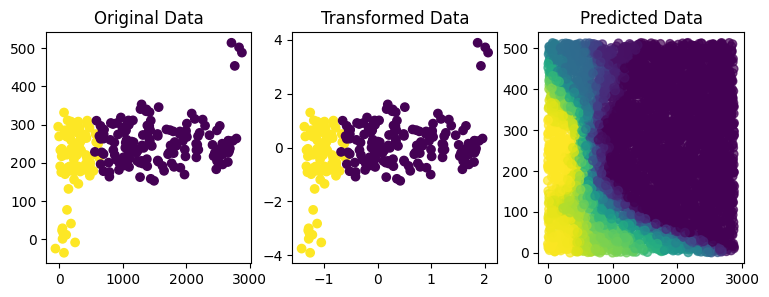

In [ ]:
plot_output(scaler=StandardScaler()) 
#outliers have an effect on the predicted data as it changes the trend

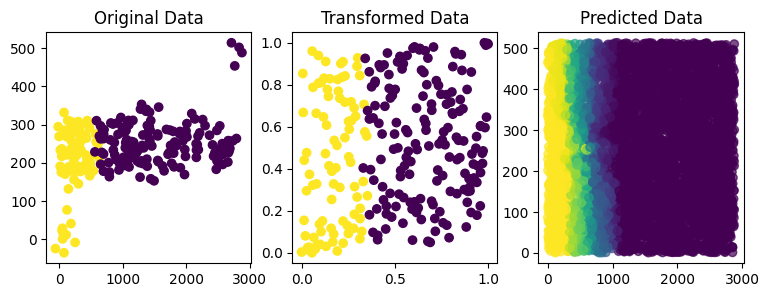

In [ ]:
plot_output(scaler=QuantileTransformer(n_quantiles=100))
#outlers dont have an effect as a clear line is drawn to classify yellow and blue

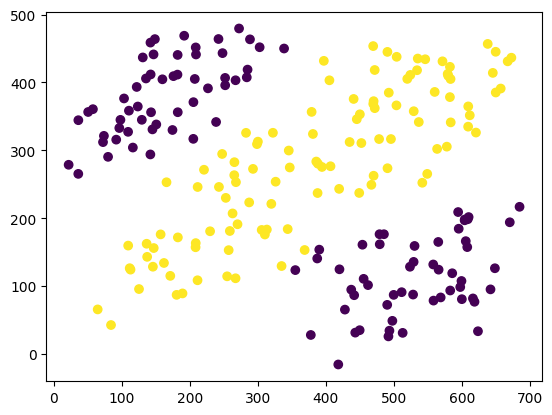

In [21]:
df1 = pd.read_csv("./public/drawndata2.csv")
X = df1[['x','y']].values
y = df1['z'] == 'a'
plt.scatter(X[:,0],X[:,1],c=y)

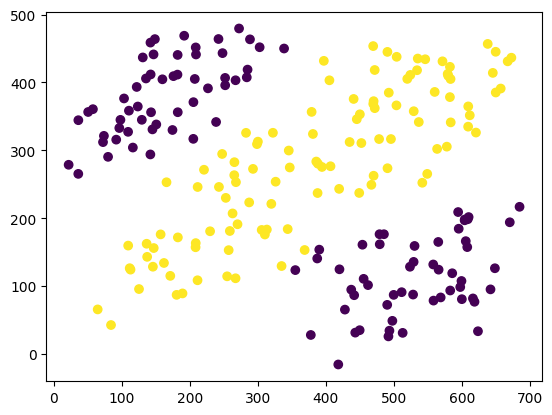

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder

pipe = Pipeline([
    ("scale", PolynomialFeatures()),
    ("model", LogisticRegression())
])

pred = pipe.fit(X,y).predict(X)
plt.scatter(X[:,0], X[:,1], c=pred)

In [27]:
arr = np.array(["low", "low", "high", "medium"]).reshape(-1,1)

In [37]:
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc.fit_transform(arr)

array([[0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.]])

In [38]:
enc.transform([["zero"]])

array([[0., 0., 0.]])